<a href="https://colab.research.google.com/github/ajaynice1996/DIY_MRI_Workshop_II_Recon/blob/main/Day2_Notebook_1_2_MRI_self_supervised_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Notebook 1.2: MRI Self-Supervised Denoising

## From noisy MRI → self-supervised learning → denoised MRI

This notebook follows **Notebook 1.1 — MRI Denoising + Deep Learning Foundations** and reuses the same workshop MRI data, normalization strategy, synthetic noise model, small CNN, losses, optimizers, and PSNR/SSIM evaluation ideas.

### Main learning goal

In the supervised notebook, the network learned:

```text
Noisy MRI ──→ CNN ──→ Clean MRI
                         ↑
                       target
```

Here we move toward **self-supervised / Noise2Noise-style learning**:

```text
Noisy view A ──→ CNN ──→ Noisy view B
                              ↑
                     independent noisy target
```

The important idea is that the training loss does **not** compare the prediction with the clean MRI.

> Critical concept: true Noise2Noise requires independent noise realizations that share the same underlying signal. Simply adding more noise to one noisy image and using that noisy image as the target does not automatically create a valid Noise2Noise problem.

---

## Notebook roadmap

### Part A — Data and preprocessing
1. Load the same MRI used in Notebook 1.1
2. Inspect the volume
3. Select a 2D slice
4. Normalize intensities
5. Create an observed noisy MRI

### Part B — Self-supervised denoising concept
6. Understand supervised vs self-supervised training
7. Understand Noise2Noise assumptions
8. Create independent noisy views
9. Verify the views visually and numerically

### Part C — Build the self-supervised CNN
10. Define a small image-to-image CNN
11. Understand tensor shapes
12. Compare MSE, L1, and combined losses
13. Choose an optimizer

### Part D — Whole-image Noise2Noise training
14. Train using the complete MRI slice
15. Monitor the loss
16. Apply the trained network to the original noisy MRI
17. Evaluate with MSE, PSNR, and SSIM
18. Inspect residual noise and artifacts

### Part E — Training variants
19. MSE vs L1 vs combined loss
20. Adam vs SGD
21. Learning-rate experiments
22. Noise-level experiments
23. Residual-learning variant

### Part F — Patch-wise self-supervised learning
24. Extract patches
25. Train using patches
26. Reconstruct the complete image
27. Evaluate patch-wise and full-image performance
28. Compare patch sizes and strides

### Part G — Critical exercises
29. What can go wrong?
30. Improve the model
31. Test generalization
32. Design your own experiment

---

# Key question

**Can a network learn to remove noise without ever being shown the clean image as its training target?**

Let's test it.


# Part A — Load and understand the MRI data

We use the same workshop dataset and the same 3T T2-weighted image from Notebook 1.1.

The 3T image is useful here as an **evaluation reference**. During self-supervised training, however, we will not provide it to the network as a target.


In [1]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

Cloning into 'DIY_MRI_Workshop_II_Recon'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 250 (delta 66), reused 15 (delta 4), pack-reused 109 (from 2)
Receiving objects: 100% (250/250), 142.66 MiB | 27.27 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [2]:
!pwd

/content


In [3]:
# ============================================================
# 1. Imports and device
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


In [4]:
# ============================================================
# 2. Workshop data path
# ============================================================

workshop_dir = "/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001"

image_path = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading:", image_path)

nii = nib.load(image_path)
volume = nii.get_fdata().astype(np.float32)

print("\nMRI information")
print("----------------")
print("Shape:", volume.shape)
print("Voxel spacing:", nii.header.get_zooms()[:3])
print("Data type:", volume.dtype)
print("Minimum:", volume.min())
print("Maximum:", volume.max())
print("Mean:", volume.mean())
print("Std:", volume.std())


Loading: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/3T/POCEMR001_T2.nii.gz

MRI information
----------------
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum: 0.0
Maximum: 255.0
Mean: 38.78939
Std: 53.17793


## Why do we work with a 2D slice?

The original MRI is a 3D volume:

```text
H × W × D
```

For this introductory workshop we use a single slice:

```text
H × W
```

This keeps the learning problem simple enough to understand while preserving the complete image-to-image denoising workflow.

Later, the same idea can be extended to:
- 2D patch training
- 2.5D input
- 3D CNNs
- slice stacks
- full 3D self-supervised reconstruction


Selected slice: 80
Slice shape: (224, 224)


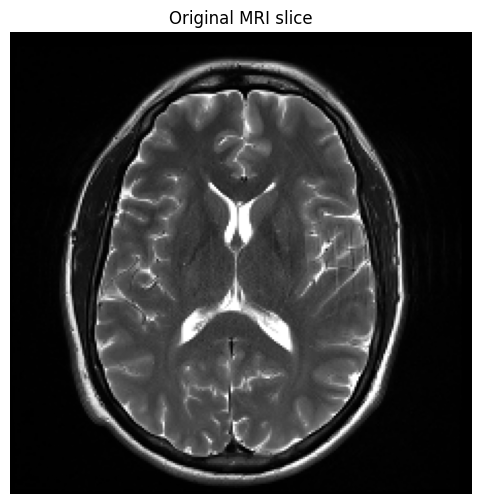

In [5]:
# ============================================================
# 3. Select a slice
# ============================================================

slice_idx = volume.shape[2] // 2

image = volume[:, :, slice_idx]

print("Selected slice:", slice_idx)
print("Slice shape:", image.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image.T, cmap="gray", origin="lower")
plt.title("Original MRI slice")
plt.axis("off")
plt.show()


# Part A.2 — MRI intensity normalization

The same MRI can contain very large numerical intensity values.

For this workshop we use **min-max normalization**:

\[
x_{norm} = \frac{x-x_{min}}{x_{max}-x_{min}}
\]

This maps the image approximately to:

```text
0 → minimum
1 → maximum
```

This is especially convenient for:
- synthetic noise generation
- CNN training
- PSNR calculation with `data_range=1.0`


Normalized minimum: 0.0
Normalized maximum: 1.0
Normalized mean: 0.17348918
Normalized std: 0.21132767


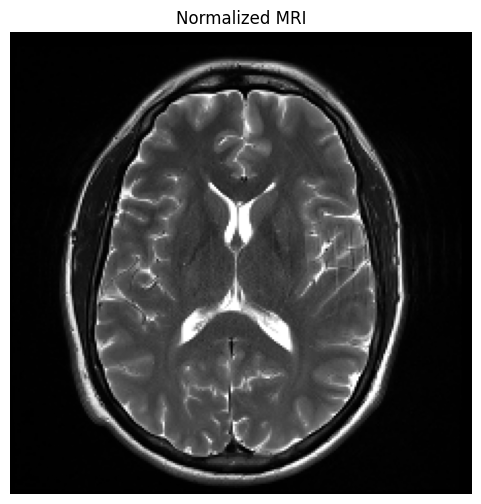

In [6]:
# ============================================================
# 4. Min-max normalization
# ============================================================

image_min = image.min()
image_max = image.max()

image_norm = (image - image_min) / (image_max - image_min + 1e-8)

print("Normalized minimum:", image_norm.min())
print("Normalized maximum:", image_norm.max())
print("Normalized mean:", image_norm.mean())
print("Normalized std:", image_norm.std())

plt.figure(figsize=(6, 6))
plt.imshow(image_norm.T, cmap="gray", origin="lower", vmin=0, vmax=1)
plt.title("Normalized MRI")
plt.axis("off")
plt.show()


## Exercise 1 — Try another normalization

Before continuing, change the normalization strategy.

Try:
1. Min-max normalization
2. Percentile normalization using the 1st and 99th percentiles
3. Z-score normalization

### Think about

- Does the visual appearance change?
- Does the noise look different?
- Does PSNR still use `data_range=1.0`?
- Which normalization makes training easiest?

Keep the min-max version as the main experiment so the notebook remains consistent.


# Part B — Create the noisy MRI

We first create the noisy observation that represents the MRI available to us.

Conceptually:

\[
y = x+n
\]

where:

- \(x\) = underlying MRI signal
- \(n\) = noise
- \(y\) = observed noisy MRI

The clean MRI will be retained for **evaluation only**.


In [7]:
# ============================================================
# 5. Synthetic noise function
# ============================================================

def add_noise(x, noise_type="gauss", noise_level=50):
    """
    Add synthetic noise to a normalized MRI.

    Gaussian:
        noise_level is specified on a 0-255 scale
        and converted to normalized sigma.

    Poisson:
        noise_level controls the sampling scale.
    """

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x.astype(np.float32))

    x = x.float()

    if noise_type == "gauss":

        sigma = noise_level / 255.0

        noise = torch.normal(
            mean=0.0,
            std=sigma,
            size=x.shape,
            device=x.device
        )

        noisy = x + noise

    elif noise_type == "poiss":

        noisy = torch.poisson(noise_level * x) / noise_level

    else:
        raise ValueError("noise_type must be 'gauss' or 'poiss'")

    return torch.clamp(noisy, 0, 1)


In [8]:
# ============================================================
# 6. Create the observed noisy MRI
# ============================================================

noise_type = "gauss"
noise_level = 50

clean_reference = torch.from_numpy(
    image_norm.astype(np.float32)
)

observed_noisy = add_noise(
    clean_reference,
    noise_type=noise_type,
    noise_level=noise_level
)

print("Noise type:", noise_type)
print("Noise level:", noise_level)
print("Observed noisy shape:", observed_noisy.shape)


Noise type: gauss
Noise level: 50
Observed noisy shape: torch.Size([224, 224])


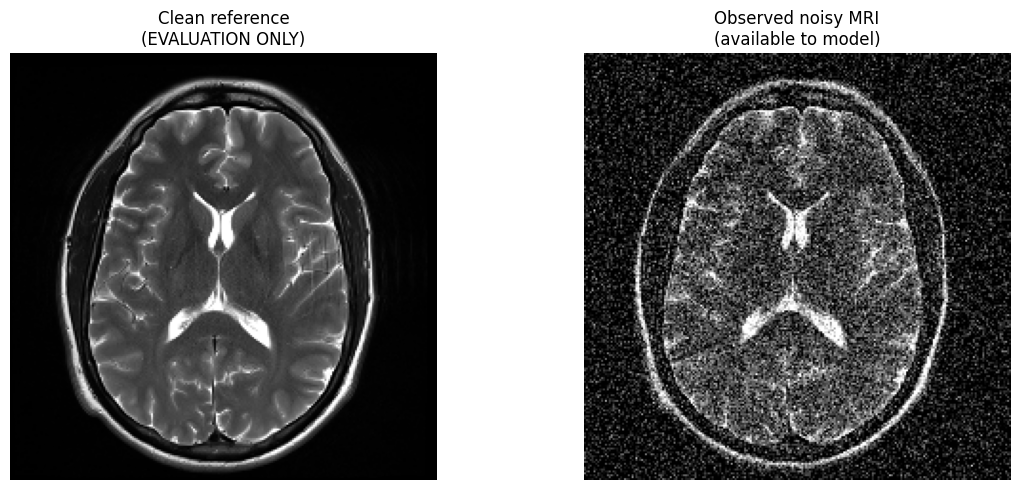

In [9]:
# ============================================================
# 7. Visualize clean reference vs observed noisy image
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(
    clean_reference.cpu().numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Clean reference\n(EVALUATION ONLY)")

axes[1].imshow(
    observed_noisy.cpu().numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[1].set_title("Observed noisy MRI\n(available to model)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Part B.1 — What changes in self-supervised learning?

### Supervised denoising

```text
Input:
    noisy MRI

Target:
    clean MRI

Loss:
    prediction ↔ clean MRI
```

The network is explicitly told what the clean answer is.

### Self-supervised Noise2Noise-style learning

```text
Input:
    noisy view A

Target:
    independent noisy view B

Loss:
    prediction ↔ noisy view B
```

The clean image is not supplied as the target.

If the noise is independent and approximately zero-mean, the expected target is related to the underlying signal.

---

# Part B.2 — Create two independent noisy views

For this controlled demonstration, we start from the same underlying normalized image and generate two independent noisy observations.

**Important:** `clean_reference` is used only to synthesize the two views. It will not be passed to the training loss.

This allows us to demonstrate the Noise2Noise principle in a controlled experiment.


In [10]:
# ============================================================
# 8. Generate two independent noisy observations
# ============================================================

torch.manual_seed(42)

noisy_A = add_noise(
    clean_reference,
    noise_type=noise_type,
    noise_level=noise_level
)

noisy_B = add_noise(
    clean_reference,
    noise_type=noise_type,
    noise_level=noise_level
)

print("Noisy A mean:", noisy_A.mean().item())
print("Noisy B mean:", noisy_B.mean().item())

difference_AB = torch.mean((noisy_A - noisy_B) ** 2).item()

print("MSE between independent noisy views:", difference_AB)


Noisy A mean: 0.21357159316539764
Noisy B mean: 0.21287353336811066
MSE between independent noisy views: 0.04662242531776428


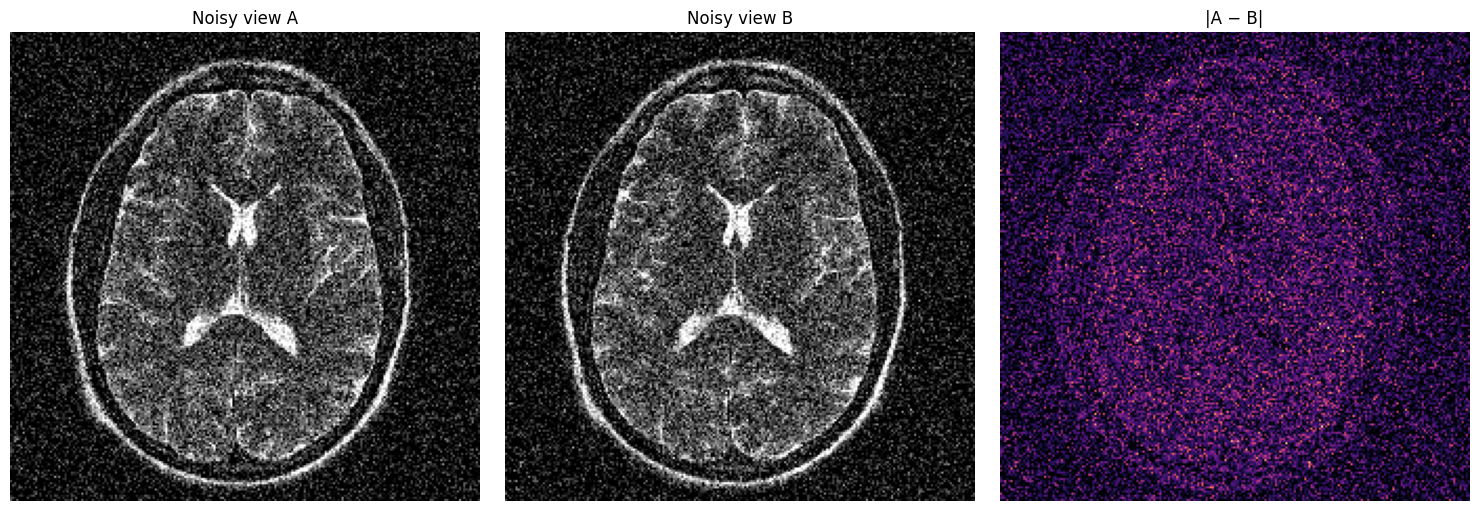

In [11]:
# ============================================================
# 9. Visualize the two independent noisy views
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(noisy_A.cpu().numpy().T, cmap="gray",
               origin="lower", vmin=0, vmax=1)
axes[0].set_title("Noisy view A")

axes[1].imshow(noisy_B.cpu().numpy().T, cmap="gray",
               origin="lower", vmin=0, vmax=1)
axes[1].set_title("Noisy view B")

axes[2].imshow(
    torch.abs(noisy_A - noisy_B).cpu().numpy().T,
    cmap="magma",
    origin="lower"
)
axes[2].set_title("|A − B|")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Exercise 2 — Are the two noise patterns identical?

Calculate:

```python
torch.mean((noisy_A - noisy_B) ** 2)
```

Then ask:

> If A and B contain the same anatomy but different noise, what should a good network learn to preserve?

Expected answer:

- preserve anatomical structure
- suppress unpredictable noise
- avoid simply copying the input


# Important warning — the "add noise to one noisy image" trap

A tempting experiment is:

```text
observed noisy MRI
        ↓
   add more noise
        ↓
     noisy A

observed noisy MRI
        ↓
   add more noise
        ↓
     noisy B
```

and then train:

```text
noisy A → noisy B
```

But both targets contain the **same original noise already present in the observed image**.

Therefore, the expectation of the target is not necessarily the clean MRI.

This can teach the network to reproduce the original noise.

### Therefore we will study two cases

**Case A — controlled Noise2Noise**

```text
same underlying MRI
      ↓
independent noise 1 → A
independent noise 2 → B
```

This is the main Noise2Noise experiment.

# Part C — Build a small self-supervised denoising CNN

We reuse the small CNN idea from Notebook 1.1.

The network receives:

```text
B × C × H × W
```

and returns an image of the same size.

No pooling is used, so spatial dimensions remain unchanged.


In [12]:
# ============================================================
# 10. Small image-to-image CNN
# ============================================================

class DenoiseCNN(nn.Module):

    def __init__(self, n_chan=1, chan_embed=48):
        super().__init__()

        self.act = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True
        )

        self.conv1 = nn.Conv2d(
            n_chan, chan_embed, kernel_size=3, padding=1
        )

        self.conv2 = nn.Conv2d(
            chan_embed, chan_embed, kernel_size=3, padding=1
        )

        self.conv3 = nn.Conv2d(
            chan_embed, n_chan, kernel_size=1
        )

    def forward(self, x):

        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x


model = DenoiseCNN(
    n_chan=1,
    chan_embed=48
).to(device)

print(model)

print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


DenoiseCNN(
  (act): LeakyReLU(negative_slope=0.2, inplace=True)
  (conv1): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(48, 1, kernel_size=(1, 1), stride=(1, 1))
)
Trainable parameters: 21313


In [13]:
# ============================================================
# 11. Prepare Noise2Noise tensors
# ============================================================

# H × W → B × C × H × W
input_A = noisy_A.unsqueeze(0).unsqueeze(0).to(device)
target_B = noisy_B.unsqueeze(0).unsqueeze(0).to(device)

# Evaluation reference only
clean_eval = clean_reference.unsqueeze(0).unsqueeze(0).to(device)

print("Input A :", input_A.shape)
print("Target B:", target_B.shape)
print("Clean evaluation reference:", clean_eval.shape)


Input A : torch.Size([1, 1, 224, 224])
Target B: torch.Size([1, 1, 224, 224])
Clean evaluation reference: torch.Size([1, 1, 224, 224])


## Critical rule

During training:

```python
prediction = model(input_A)
loss = loss_function(prediction, target_B)
```

**Not:**

```python
loss = loss_function(prediction, clean_eval)
```

`clean_eval` is reserved for the final evaluation.

This is what makes the experiment self-supervised with respect to the clean target.


# Part C.1 — Loss functions

The loss tells the network how wrong its prediction is.

We will test:

### MSE

Large errors receive more emphasis.

### L1 / MAE

Less sensitive to large individual errors.

### Combined loss


Students can later experiment with the weights. Understand the hybrid loss function.


In [15]:
# ============================================================
# 12. Loss functions
# ============================================================

def combined_loss(
    prediction,
    target,
    lambda_mse=0.5,
    lambda_l1=0.5
):
    mse = F.mse_loss(prediction, target)
    l1 = F.l1_loss(prediction, target)

    total = (
        lambda_mse * mse
        + lambda_l1 * l1
    )

    return total, mse, l1


# Example before training
with torch.no_grad():
    initial_prediction = model(input_A)

mse_value = F.mse_loss(
    initial_prediction,
    target_B
).item()

l1_value = F.l1_loss(
    initial_prediction,
    target_B
).item()

print("Initial MSE:", mse_value)
print("Initial L1 :", l1_value)

Initial MSE: 0.06981068849563599
Initial L1 : 0.18808597326278687


# Part C.2 — Optimizer

The optimizer updates the CNN parameters using the gradient of the loss.

For this workshop we start with **Adam**.

```text
prediction
    ↓
loss
    ↓
backpropagation
    ↓
gradients
    ↓
Adam
    ↓
updated CNN
```

Starting parameters:

- optimizer: Adam
- learning rate: `1e-3`
- steps: 1000


In [16]:
# ============================================================
# 13. Optimizer
# ============================================================

learning_rate = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print(optimizer)


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Part D — Whole-image self-supervised training

We now train using the **entire 2D MRI slice**.

Training pair:

```text
Noisy A ──→ CNN ──→ Prediction
                       │
                       ▼
                    Noisy B
```

The clean reference is not used in the loss.


In [20]:
# ============================================================
# 14. Whole-image Noise2Noise training
# ============================================================

num_steps = 1000

loss_history = []

model.train()

for step in range(num_steps):

    optimizer.zero_grad()

    # Forward pass
    prediction = model(input_A)

    # Self-supervised target = independent noisy view B
    loss = F.mse_loss(
        prediction,
        target_B
    )

    # Backpropagation
    loss.backward()

    # Parameter update
    optimizer.step()

    loss_history.append(loss.item())

    if (step + 1) % 100 == 0:
        print(
            f"Step {step + 1:04d} | "
            f"Self-supervised MSE: {loss.item():.6f}"
        )


Step 0100 | Self-supervised MSE: 0.022326
Step 0200 | Self-supervised MSE: 0.022228
Step 0300 | Self-supervised MSE: 0.022484
Step 0400 | Self-supervised MSE: 0.022065
Step 0500 | Self-supervised MSE: 0.021868
Step 0600 | Self-supervised MSE: 0.021770
Step 0700 | Self-supervised MSE: 0.021697
Step 0800 | Self-supervised MSE: 0.021586
Step 0900 | Self-supervised MSE: 0.021512
Step 1000 | Self-supervised MSE: 0.021474


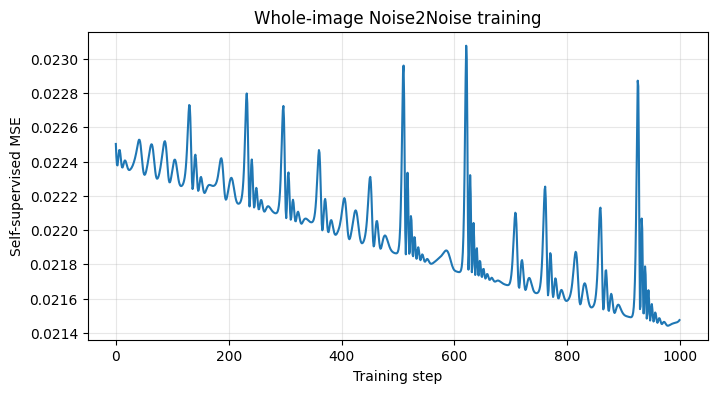

In [21]:
# ============================================================
# 15. Plot training loss
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(loss_history)

plt.xlabel("Training step")
plt.ylabel("Self-supervised MSE")
plt.title("Whole-image Noise2Noise training")

plt.grid(alpha=0.3)
plt.show()


## What should we look for?

A decreasing training loss means the network is learning to map noisy A toward noisy B.

But:

> **A lower self-supervised training loss does not automatically mean better denoising.**

A network could reduce the loss by learning an undesirable mapping.

Therefore we must inspect:
- visual appearance
- PSNR
- SSIM
- residual noise
- anatomical detail
- artifacts

This is an important distinction between **optimization performance** and **scientific validity**.


# Part D.1 — Apply the trained network to the original noisy MRI

Now we use the trained model on the original observed noisy image.

```text
Observed noisy MRI
        ↓
      CNN
        ↓
Denoised prediction
```

The clean MRI is still not used as an input.


In [22]:
# ============================================================
# 16. Apply model to the observed noisy MRI
# ============================================================

observed_input = observed_noisy.unsqueeze(0).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    denoised = model(observed_input)

# Keep output in a valid display range
denoised = torch.clamp(denoised, 0, 1)

print("Observed input shape:", observed_input.shape)
print("Denoised shape:", denoised.shape)


Observed input shape: torch.Size([1, 1, 224, 224])
Denoised shape: torch.Size([1, 1, 224, 224])


# Part D.2 — Evaluation metrics

For this workshop, we have a clean reference available.

That clean reference is **not part of training**.

It is used here to answer:

> Did the self-supervised model actually remove noise?

We calculate:

- MSE ↓
- PSNR ↑
- SSIM ↑


In [23]:
# ============================================================
# 17. Evaluation functions
# ============================================================

def calculate_psnr(reference, prediction, data_range=1.0):

    mse = np.mean(
        (reference - prediction) ** 2
    )

    if mse == 0:
        return float("inf")

    return 10 * np.log10(
        (data_range ** 2) / mse
    )


clean_np = clean_eval[0, 0].detach().cpu().numpy()
noisy_np = observed_input[0, 0].detach().cpu().numpy()
denoised_np = denoised[0, 0].detach().cpu().numpy()

mse_noisy = np.mean(
    (clean_np - noisy_np) ** 2
)

mse_denoised = np.mean(
    (clean_np - denoised_np) ** 2
)

psnr_noisy = calculate_psnr(
    clean_np,
    noisy_np,
    data_range=1.0
)

psnr_denoised = calculate_psnr(
    clean_np,
    denoised_np,
    data_range=1.0
)

ssim_noisy = ssim(
    clean_np,
    noisy_np,
    data_range=1.0
)

ssim_denoised = ssim(
    clean_np,
    denoised_np,
    data_range=1.0
)

print("                 Noisy        Denoised")
print("----------------------------------------")
print(f"MSE            {mse_noisy:.6f}    {mse_denoised:.6f}")
print(f"PSNR           {psnr_noisy:.2f} dB      {psnr_denoised:.2f} dB")
print(f"SSIM           {ssim_noisy:.4f}       {ssim_denoised:.4f}")


                 Noisy        Denoised
----------------------------------------
MSE            0.025902    0.009559
PSNR           15.87 dB      20.20 dB
SSIM           0.2612       0.3848


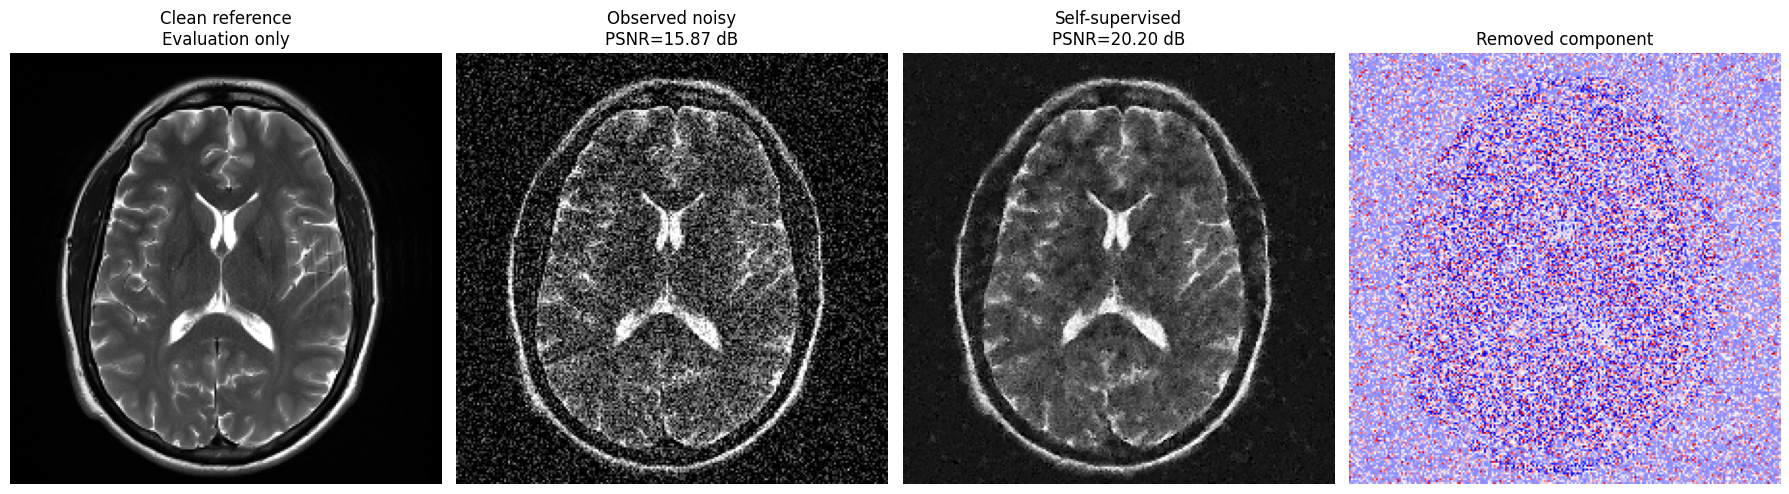

In [24]:
# ============================================================
# 18. Visual comparison
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(
    clean_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Clean reference\nEvaluation only")

axes[1].imshow(
    noisy_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[1].set_title(
    f"Observed noisy\nPSNR={psnr_noisy:.2f} dB"
)

axes[2].imshow(
    denoised_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[2].set_title(
    f"Self-supervised\nPSNR={psnr_denoised:.2f} dB"
)

residual = noisy_np - denoised_np

axes[3].imshow(
    residual.T,
    cmap="seismic",
    origin="lower"
)
axes[3].set_title("Removed component")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Critical interpretation

If the denoised image has:

- **higher PSNR**
- **higher SSIM**
- visually reduced noise
- preserved anatomy

then the self-supervised model is behaving as intended.

However, do not judge the model from PSNR alone.

### Watch for

**Over-smoothing**

```text
noise ↓
but
fine anatomy ↓
```

**Hallucination**

```text
network creates structures
that were not present
```

**Residual noise**

```text
noise remains after denoising
```

**Bias**

```text
some tissue regions improve
while others degrade
```

For medical imaging, visual and task-based validation are important.


# Part E — Training Variant 1: MSE vs L1 vs Combined Loss

A major learning exercise is to keep everything fixed and change only the loss.

### Experiment

Run the whole-image experiment three times:

1. MSE
2. L1
3. 50% MSE + 50% L1

Record:

| Loss | Final self-supervised loss | PSNR | SSIM | Visual quality |
|---|---:|---:|---:|---|
| MSE | | | | |
| L1 | | | | |
| MSE + L1 | | | | |

### Question

Does the loss that gives the smallest training value necessarily give the best image?


In [25]:
# ============================================================
# 19. Helper function for loss experiments
# ============================================================

def train_whole_image(
    input_image,
    target_image,
    loss_name="mse",
    lr=1e-3,
    steps=500,
    chan_embed=48
):

    experiment_model = DenoiseCNN(
        n_chan=1,
        chan_embed=chan_embed
    ).to(device)

    experiment_optimizer = optim.Adam(
        experiment_model.parameters(),
        lr=lr
    )

    losses = []

    experiment_model.train()

    for step in range(steps):

        experiment_optimizer.zero_grad()

        pred = experiment_model(input_image)

        if loss_name == "mse":
            loss = F.mse_loss(pred, target_image)

        elif loss_name == "l1":
            loss = F.l1_loss(pred, target_image)

        elif loss_name == "combined":
            loss, _, _ = combined_loss(
                pred,
                target_image,
                lambda_mse=0.5,
                lambda_l1=0.5
            )

        else:
            raise ValueError(
                "loss_name must be mse, l1, or combined"
            )

        loss.backward()
        experiment_optimizer.step()

        losses.append(loss.item())

    experiment_model.eval()

    with torch.no_grad():
        result = torch.clamp(
            experiment_model(input_image),
            0,
            1
        )

    return experiment_model, losses, result


In [26]:
# ============================================================
# 20. Run a quick loss comparison
# ============================================================

loss_variants = ["mse", "l1", "combined"]

loss_results = {}

for loss_name in loss_variants:

    print("\nTraining:", loss_name)

    test_model, losses, result = train_whole_image(
        input_A,
        target_B,
        loss_name=loss_name,
        lr=1e-3,
        steps=500,
        chan_embed=48
    )

    result_np = result[0, 0].detach().cpu().numpy()

    loss_results[loss_name] = {
        "loss": losses,
        "prediction": result_np,
        "psnr": calculate_psnr(
            clean_np,
            result_np
        ),
        "ssim": ssim(
            clean_np,
            result_np,
            data_range=1.0
        )
    }

    print(
        f"Evaluation PSNR: "
        f"{loss_results[loss_name]['psnr']:.2f} dB"
    )

    print(
        f"Evaluation SSIM: "
        f"{loss_results[loss_name]['ssim']:.4f}"
    )



Training: mse
Evaluation PSNR: 21.72 dB
Evaluation SSIM: 0.4781

Training: l1
Evaluation PSNR: 24.25 dB
Evaluation SSIM: 0.6541

Training: combined
Evaluation PSNR: 23.95 dB
Evaluation SSIM: 0.5556


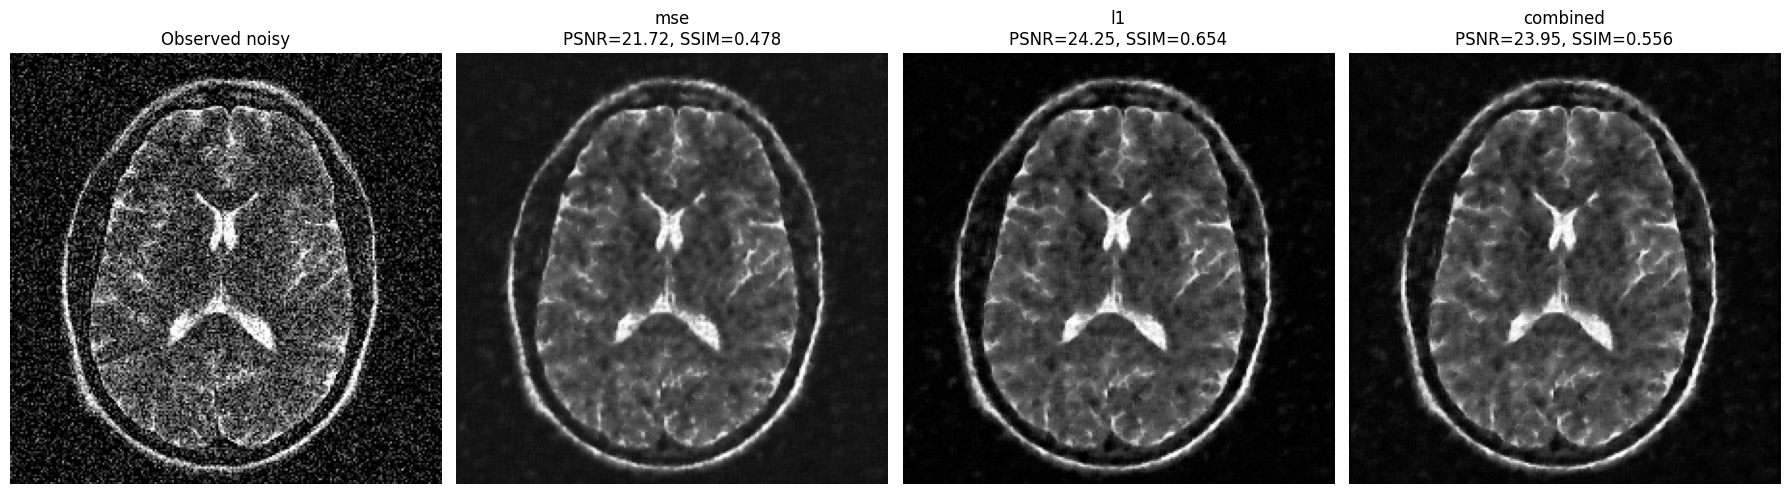

In [27]:
# ============================================================
# 21. Compare loss variants visually
# ============================================================

fig, axes = plt.subplots(
    1,
    len(loss_variants) + 1,
    figsize=(18, 5)
)

axes[0].imshow(
    noisy_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Observed noisy")

for i, loss_name in enumerate(loss_variants, start=1):

    result_np = loss_results[loss_name]["prediction"]

    axes[i].imshow(
        result_np.T,
        cmap="gray",
        origin="lower",
        vmin=0,
        vmax=1
    )

    axes[i].set_title(
        f"{loss_name}\n"
        f"PSNR={loss_results[loss_name]['psnr']:.2f}, "
        f"SSIM={loss_results[loss_name]['ssim']:.3f}"
    )

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Training Variant 2 — Learning rate

The learning rate controls how large each parameter update is.

Try:

```text
1e-2
1e-3
1e-4
1e-5
```

### Typical observations

Too large:

```text
loss jumps
unstable training
poor image
```

Too small:

```text
very slow learning
little improvement
```

Reasonable:

```text
loss decreases
training is stable
image improves
```

### Exercise

Change only:

```python
lr=
```

Keep all other parameters identical.


In [28]:
# ============================================================
# 22. Learning-rate experiment
# ============================================================

learning_rates = [1e-2, 1e-3, 1e-4]

lr_results = {}

for lr in learning_rates:

    print("\nLearning rate:", lr)

    _, losses, result = train_whole_image(
        input_A,
        target_B,
        loss_name="mse",
        lr=lr,
        steps=300,
        chan_embed=48
    )

    result_np = result[0, 0].detach().cpu().numpy()

    lr_results[lr] = {
        "loss": losses,
        "psnr": calculate_psnr(clean_np, result_np),
        "ssim": ssim(
            clean_np,
            result_np,
            data_range=1.0
        )
    }

    print(
        "PSNR:",
        f"{lr_results[lr]['psnr']:.2f} dB"
    )

    print(
        "SSIM:",
        f"{lr_results[lr]['ssim']:.4f}"
    )



Learning rate: 0.01
PSNR: 21.51 dB
SSIM: 0.4724

Learning rate: 0.001
PSNR: 21.27 dB
SSIM: 0.4592

Learning rate: 0.0001
PSNR: 20.91 dB
SSIM: 0.4386


# Training Variant 3 — Noise level

The model may behave very differently depending on the noise level.

Try:

```python
noise_levels = [10, 25, 50, 75, 100]
```

Questions:

1. Is mild noise easier to remove?
2. At what level does anatomy begin to disappear?
3. Does a model trained at one noise level generalize to another?
4. Does training with multiple noise levels improve robustness?


In [29]:
# ============================================================
# 23. Noise-level study
# ============================================================

noise_levels = [10, 25, 50, 75, 100]

for nl in noise_levels:

    view_A = add_noise(
        clean_reference,
        noise_type="gauss",
        noise_level=nl
    )

    view_B = add_noise(
        clean_reference,
        noise_type="gauss",
        noise_level=nl
    )

    print(
        f"Noise level {nl:3d} | "
        f"A-B MSE = "
        f"{torch.mean((view_A - view_B) ** 2).item():.6f}"
    )


Noise level  10 | A-B MSE = 0.002198
Noise level  25 | A-B MSE = 0.012887
Noise level  50 | A-B MSE = 0.045822
Noise level  75 | A-B MSE = 0.090747
Noise level 100 | A-B MSE = 0.141343


# Training Variant 4 — Residual learning

Instead of asking the network to directly predict the denoised image:

```text
noisy → CNN → clean estimate
```

we can ask it to predict the residual/noise:

```text
noisy → CNN → estimated noise
                 ↓
noisy − estimated noise
                 ↓
          denoised image
```

This is often useful in image restoration because the residual may be simpler to learn.

### Exercise

Implement a residual CNN.

Compare:

- direct image prediction
- residual prediction

using the same:
- noise
- patch size
- optimizer
- learning rate
- number of steps


In [30]:
# ============================================================
# 24. Residual-learning CNN
# ============================================================

class ResidualDenoiseCNN(nn.Module):

    def __init__(self, n_chan=1, chan_embed=48):
        super().__init__()

        self.act = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True
        )

        self.conv1 = nn.Conv2d(
            n_chan, chan_embed, 3, padding=1
        )

        self.conv2 = nn.Conv2d(
            chan_embed, chan_embed, 3, padding=1
        )

        self.conv3 = nn.Conv2d(
            chan_embed, n_chan, 1
        )

    def forward(self, x):

        residual = self.act(self.conv1(x))
        residual = self.act(self.conv2(residual))
        residual = self.conv3(residual)

        return x - residual


residual_model = ResidualDenoiseCNN().to(device)

print(residual_model)


ResidualDenoiseCNN(
  (act): LeakyReLU(negative_slope=0.2, inplace=True)
  (conv1): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(48, 1, kernel_size=(1, 1), stride=(1, 1))
)


# Part F — Patch-wise self-supervised training

Whole-image training is simple, but it has limitations.

A single image gives us only one training example:

```text
1 MRI slice → 1 input → 1 target
```

Patch extraction turns it into many examples:

```text
MRI
 ↓
64×64 patch 1
64×64 patch 2
64×64 patch 3
...
```

This can:
- increase the number of training examples
- reduce memory requirements
- expose the network to different local structures
- make experiments faster

But patch training can also introduce:
- border artifacts
- loss of global context
- biased sampling
- too many background patches


In [31]:
# ============================================================
# 25. Patch extraction
# ============================================================

def extract_patches(
    image_tensor,
    patch_size=64,
    stride=32
):
    """
    Extract 2D patches from an H x W tensor.
    Returns a tensor of shape N x 1 x patch_size x patch_size.
    """

    if image_tensor.ndim == 2:
        image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)

    elif image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    patches = F.unfold(
        image_tensor,
        kernel_size=patch_size,
        stride=stride
    )

    n_patches = patches.shape[-1]

    patches = patches.transpose(1, 2)

    patches = patches.reshape(
        n_patches,
        1,
        patch_size,
        patch_size
    )

    return patches


patch_size = 64
stride = 32

patches_A = extract_patches(
    noisy_A,
    patch_size=patch_size,
    stride=stride
)

patches_B = extract_patches(
    noisy_B,
    patch_size=patch_size,
    stride=stride
)

print("Patch tensor:", patches_A.shape)
print("Number of patches:", patches_A.shape[0])


Patch tensor: torch.Size([36, 1, 64, 64])
Number of patches: 36


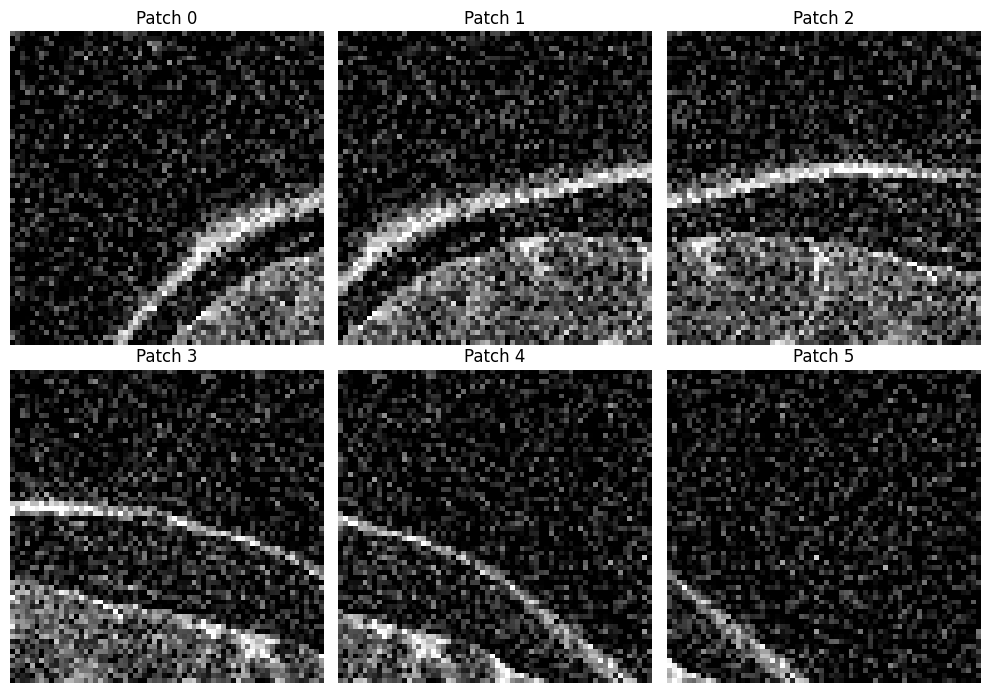

In [32]:
# ============================================================
# 26. Visualize example patches
# ============================================================

num_show = min(6, patches_A.shape[0])

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for i, ax in enumerate(axes.flat[:num_show]):

    ax.imshow(
        patches_A[i, 0].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(f"Patch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Part F.1 — Train on patches

The training objective remains:

```text
Noisy patch A
      ↓
     CNN
      ↓
Prediction
      ↓
compare with
      ↓
Noisy patch B
```

The clean patch is never used in the training loss.


In [33]:
# ============================================================
# 27. Patch-wise training function
# ============================================================

def train_patchwise(
    patches_input,
    patches_target,
    patch_size=64,
    lr=1e-3,
    epochs=20,
    chan_embed=48,
    loss_name="mse"
):

    model = DenoiseCNN(
        n_chan=1,
        chan_embed=chan_embed
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    x = patches_input.to(device)
    y = patches_target.to(device)

    losses = []

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        pred = model(x)

        if loss_name == "mse":
            loss = F.mse_loss(pred, y)

        elif loss_name == "l1":
            loss = F.l1_loss(pred, y)

        else:
            loss, _, _ = combined_loss(
                pred,
                y,
                lambda_mse=0.5,
                lambda_l1=0.5
            )

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch + 1:03d} | "
                f"Loss: {loss.item():.6f}"
            )

    return model, losses


In [34]:
# ============================================================
# 28. Run patch-wise training
# ============================================================

patch_model, patch_loss_history = train_patchwise(
    patches_A,
    patches_B,
    patch_size=patch_size,
    lr=1e-3,
    epochs=50,
    chan_embed=48,
    loss_name="mse"
)


Epoch 005 | Loss: 0.050413
Epoch 010 | Loss: 0.035416
Epoch 015 | Loss: 0.033544
Epoch 020 | Loss: 0.032063
Epoch 025 | Loss: 0.032515
Epoch 030 | Loss: 0.031953
Epoch 035 | Loss: 0.031442
Epoch 040 | Loss: 0.031477
Epoch 045 | Loss: 0.031331
Epoch 050 | Loss: 0.031275


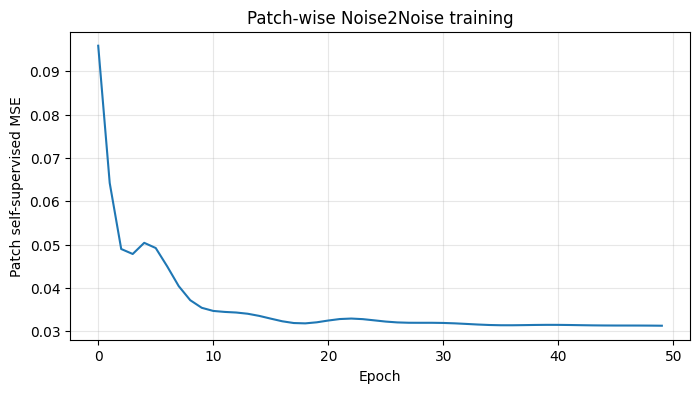

In [35]:
# ============================================================
# 29. Patch training loss
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(patch_loss_history)

plt.xlabel("Epoch")
plt.ylabel("Patch self-supervised MSE")
plt.title("Patch-wise Noise2Noise training")

plt.grid(alpha=0.3)
plt.show()


# Part F.2 — Patch-wise prediction

We can evaluate individual patches directly.

This teaches an important distinction:

### Patch-level evaluation

```text
patch → model → patch prediction → metric
```

### Full-image evaluation

```text
full image
   ↓
extract patches
   ↓
predict patches
   ↓
reconstruct image
   ↓
metric
```

The second is more relevant to the final denoised MRI.


In [36]:
# ============================================================
# 30. Patch-wise evaluation
# ============================================================

patch_model.eval()

with torch.no_grad():
    patch_predictions = torch.clamp(
        patch_model(
            patches_A.to(device)
        ),
        0,
        1
    ).cpu()

clean_patches = extract_patches(
    clean_reference,
    patch_size=patch_size,
    stride=stride
)

patch_psnrs = []

for i in range(patch_predictions.shape[0]):

    ref = clean_patches[i, 0].numpy()
    pred = patch_predictions[i, 0].numpy()

    patch_psnrs.append(
        calculate_psnr(
            ref,
            pred,
            data_range=1.0
        )
    )

print("Number of evaluated patches:", len(patch_psnrs))
print("Mean patch PSNR:", np.mean(patch_psnrs))
print("Median patch PSNR:", np.median(patch_psnrs))
print("Minimum patch PSNR:", np.min(patch_psnrs))
print("Maximum patch PSNR:", np.max(patch_psnrs))


Number of evaluated patches: 36
Mean patch PSNR: 20.533348
Median patch PSNR: 20.24662
Minimum patch PSNR: 19.435415
Maximum patch PSNR: 22.06842


# Part F.3 — Reconstruct the full image from overlapping patches

If stride is smaller than patch size:

```text
patch size = 64
stride     = 32
```

patches overlap.

We reconstruct the image by averaging the overlapping predictions.

This is a simple and useful strategy for the workshop.


In [37]:
# ============================================================
# 31. Reconstruct image from patch predictions
# ============================================================

def reconstruct_from_patches(
    patches,
    output_shape,
    patch_size=64,
    stride=32
):

    if patches.ndim == 3:
        patches = patches.unsqueeze(1)

    B, C, H, W = 1, 1, output_shape[0], output_shape[1]

    output = torch.zeros(
        (B, C, H, W),
        dtype=patches.dtype
    )

    count = torch.zeros_like(output)

    idx = 0

    for i in range(0, H - patch_size + 1, stride):

        for j in range(0, W - patch_size + 1, stride):

            output[
                0, 0,
                i:i+patch_size,
                j:j+patch_size
            ] += patches[idx, 0]

            count[
                0, 0,
                i:i+patch_size,
                j:j+patch_size
            ] += 1

            idx += 1

    output = output / (count + 1e-8)

    return output


patch_denoised = reconstruct_from_patches(
    patch_predictions,
    output_shape=clean_reference.shape,
    patch_size=patch_size,
    stride=stride
)

patch_denoised_np = patch_denoised[0, 0].numpy()

print("Reconstructed shape:", patch_denoised_np.shape)


Reconstructed shape: (224, 224)


In [38]:
# ============================================================
# 32. Compare whole-image and patch-wise results
# ============================================================

patch_psnr_full = calculate_psnr(
    clean_np,
    patch_denoised_np
)

patch_ssim_full = ssim(
    clean_np,
    patch_denoised_np,
    data_range=1.0
)

print("Patch-reconstructed full-image metrics")
print("----------------------------------------")
print(f"PSNR: {patch_psnr_full:.2f} dB")
print(f"SSIM: {patch_ssim_full:.4f}")


Patch-reconstructed full-image metrics
----------------------------------------
PSNR: 20.33 dB
SSIM: 0.4305


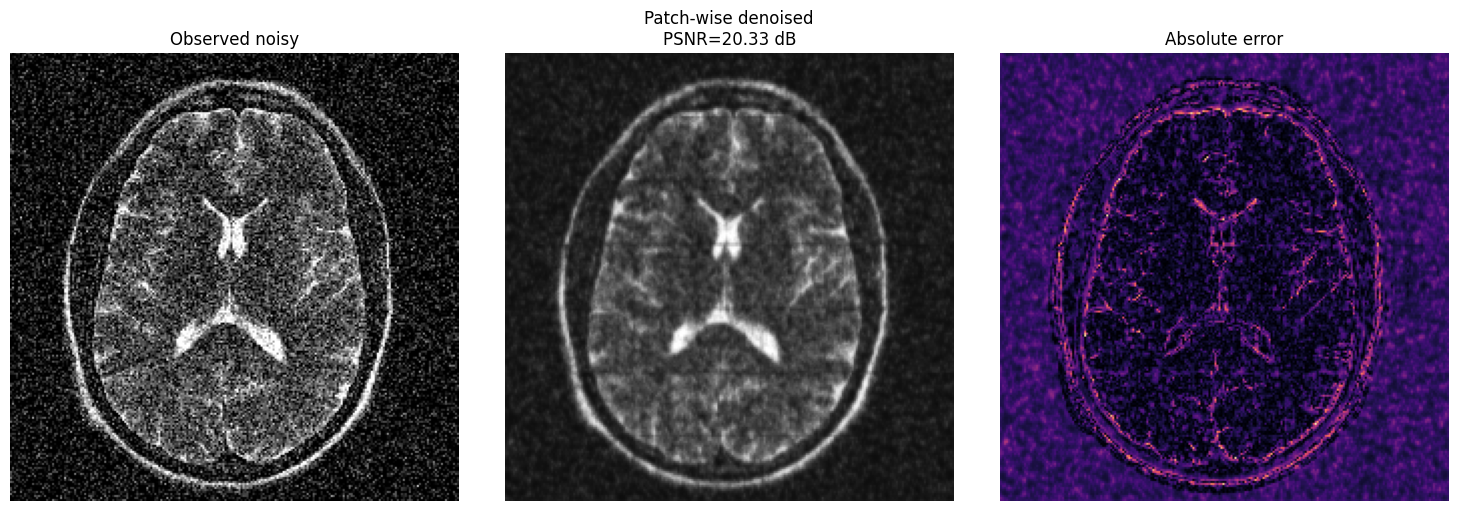

In [39]:
# ============================================================
# 33. Visualize patch reconstruction
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    noisy_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Observed noisy")

axes[1].imshow(
    patch_denoised_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[1].set_title(
    f"Patch-wise denoised\n"
    f"PSNR={patch_psnr_full:.2f} dB"
)

axes[2].imshow(
    np.abs(clean_np - patch_denoised_np).T,
    cmap="magma",
    origin="lower"
)
axes[2].set_title("Absolute error")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Part F.4 — Patch-size experiment

Try:

```text
32 × 32
64 × 64
96 × 96
128 × 128
```

### Smaller patches

Advantages:
- more local examples
- lower memory
- faster experiments

Disadvantages:
- less anatomical context
- more boundary effects

### Larger patches

Advantages:
- more context
- better representation of larger structures

Disadvantages:
- fewer patches
- higher memory
- potentially slower

### Exercise

Record:

| Patch size | Number of patches | PSNR | SSIM | Visual quality |
|---:|---:|---:|---:|---|
| 32 | | | | |
| 64 | | | | |
| 96 | | | | |
| 128 | | | | |


# Part F.5 — Stride experiment

Stride controls the overlap between patches.

For a 64×64 patch:

```text
stride = 64 → no overlap
stride = 32 → 50% overlap
stride = 16 → high overlap
```

Try different values.

### Question

Does more overlap always improve the final image?

Consider:
- computation
- number of training samples
- reconstruction smoothness
- boundary artifacts


# Part G — Single noisy image: a more realistic self-supervised problem

Suppose the scanner gives us only:

```text
ONE noisy MRI
```

There is no second independently acquired noisy image.

The previous Noise2Noise experiment cannot simply assume a second independent observation exists.

A useful family of approaches is **masking / blind-spot self-supervision**, commonly associated with Noise2Void-style ideas.

The key idea:

```text
Noisy image
    ↓
hide selected pixels
    ↓
predict hidden pixels from surrounding context
```

The network cannot simply copy the masked pixel.

This is different from Noise2Noise, but it is often more appropriate when only one noisy image is available.


## Simplified masking experiment

We will randomly mask pixels and train the CNN to reconstruct the original noisy image at those locations.

For the simplest demonstration:

```text
input  = masked noisy image
target = original noisy image
loss   = only on masked pixels
```

This means the network is never rewarded for copying the masked pixel itself.

### Important limitation

This is an educational simplified implementation, not a production Noise2Void implementation.

For serious MRI research, masking strategy, blind-spot architecture, correlated noise, Rician/noncentral-χ noise, spatially varying noise, and validation design need careful consideration.


In [40]:
# ============================================================
# 34. Create a random pixel mask
# ============================================================

def create_random_mask(
    image_tensor,
    mask_fraction=0.10
):

    mask = (
        torch.rand_like(image_tensor)
        < mask_fraction
    )

    return mask


mask_fraction = 0.10

mask = create_random_mask(
    observed_noisy,
    mask_fraction=mask_fraction
)

masked_input = observed_noisy.clone()

# Replace masked pixels with local/global neutral value.
# For this simple workshop experiment, use the image mean.
fill_value = observed_noisy.mean()

masked_input[mask] = fill_value

print("Mask fraction:", mask.float().mean().item())


Mask fraction: 0.10068558901548386


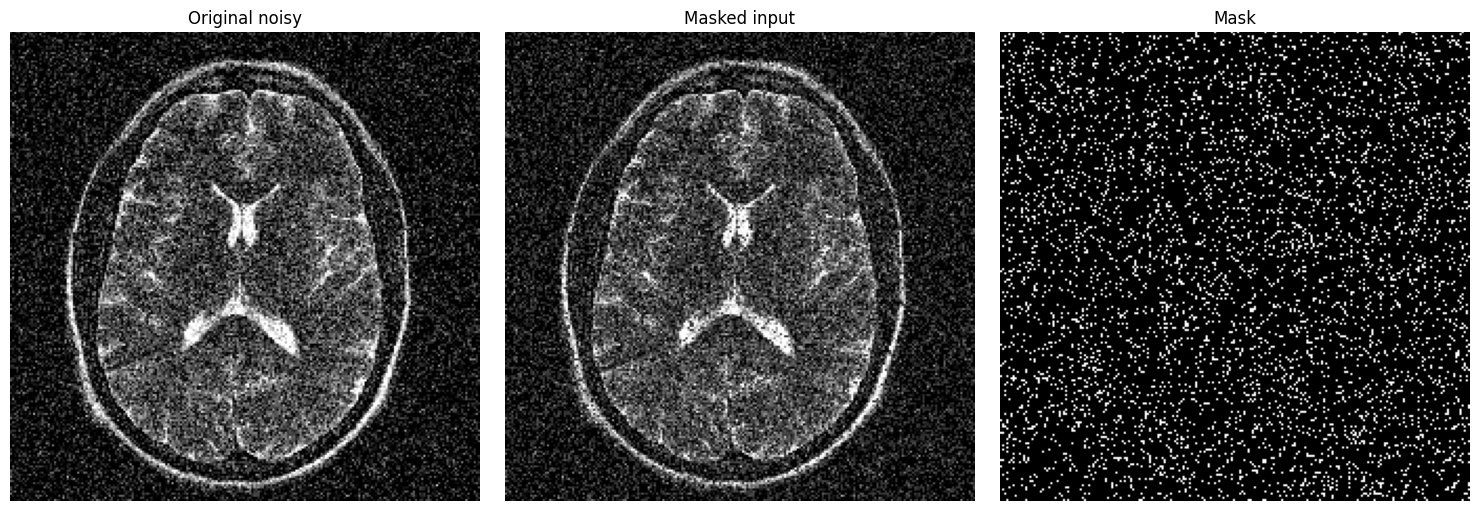

In [41]:
# ============================================================
# 35. Visualize masked input
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    observed_noisy.numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Original noisy")

axes[1].imshow(
    masked_input.numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[1].set_title("Masked input")

axes[2].imshow(
    mask.numpy().T,
    cmap="gray",
    origin="lower"
)
axes[2].set_title("Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [42]:
# ============================================================
# 36. Masked self-supervised training
# ============================================================

mask_input = masked_input.unsqueeze(0).unsqueeze(0).to(device)
mask_target = observed_noisy.unsqueeze(0).unsqueeze(0).to(device)

mask_bool = mask.unsqueeze(0).unsqueeze(0).to(device)

mask_model = DenoiseCNN().to(device)

mask_optimizer = optim.Adam(
    mask_model.parameters(),
    lr=1e-3
)

mask_losses = []

for step in range(1000):

    mask_optimizer.zero_grad()

    pred = mask_model(mask_input)

    # Only calculate loss at masked pixels
    masked_error = (
        (pred - mask_target) ** 2
    )

    loss = masked_error[mask_bool].mean()

    loss.backward()

    mask_optimizer.step()

    mask_losses.append(loss.item())

    if (step + 1) % 100 == 0:
        print(
            f"Step {step+1:04d} | "
            f"Masked loss: {loss.item():.6f}"
        )


Step 0100 | Masked loss: 0.028841
Step 0200 | Masked loss: 0.028310
Step 0300 | Masked loss: 0.027671
Step 0400 | Masked loss: 0.026856
Step 0500 | Masked loss: 0.025526
Step 0600 | Masked loss: 0.023771
Step 0700 | Masked loss: 0.022151
Step 0800 | Masked loss: 0.020713
Step 0900 | Masked loss: 0.019273
Step 1000 | Masked loss: 0.018101


In [43]:
# ============================================================
# 37. Apply masked self-supervised model
# ============================================================

mask_model.eval()

with torch.no_grad():

    masked_prediction = torch.clamp(
        mask_model(
            observed_noisy.unsqueeze(0).unsqueeze(0).to(device)
        ),
        0,
        1
    )

masked_prediction_np = (
    masked_prediction[0, 0]
    .detach()
    .cpu()
    .numpy()
)

masked_psnr = calculate_psnr(
    clean_np,
    masked_prediction_np
)

masked_ssim = ssim(
    clean_np,
    masked_prediction_np,
    data_range=1.0
)

print(f"Masked self-supervised PSNR: {masked_psnr:.2f} dB")
print(f"Masked self-supervised SSIM: {masked_ssim:.4f}")


Masked self-supervised PSNR: 16.01 dB
Masked self-supervised SSIM: 0.3107


# Part H — Critical experiments for students

The goal is not just to run the notebook.

The goal is to **change one variable, predict what will happen, run the experiment, and explain the result.**

---

## Exercise 3 — Model capacity

Change:

```python
chan_embed = 16
chan_embed = 32
chan_embed = 48
chan_embed = 64
chan_embed = 96
```

Record:

- parameter count
- training speed
- final loss
- PSNR
- SSIM
- visual quality

### Question

Does a larger CNN always produce better denoising?

---

## Exercise 4 — Number of training steps

Try:

```text
100
500
1000
2000
5000
```

Look for:

- underfitting
- useful learning
- overfitting to a noisy target
- oversmoothing

---

## Exercise 5 — Noise strength

Try:

```text
σ ≈ 10/255
σ ≈ 25/255
σ ≈ 50/255
σ ≈ 75/255
σ ≈ 100/255
```

Does the same network work equally well?

---

## Exercise 6 — Noise model

Compare:

```python
noise_type = "gauss"
```

with:

```python
noise_type = "poiss"
```

### Question

Does a method trained for Gaussian noise work well for Poisson noise?

---

## Exercise 7 — Optimizer

Compare:

```python
Adam(lr=1e-3)
```

and:

```python
SGD(lr=1e-2, momentum=0.9)
```

Compare convergence speed and final image quality.

---

## Exercise 8 — Patch size

Compare:

```text
32
64
96
128
```

Which provides the best balance between local detail and contextual information?

---

## Exercise 9 — Patch overlap

Compare:

```text
stride = patch_size
stride = patch_size // 2
stride = patch_size // 4
```

Does overlap reduce reconstruction artifacts?

---

## Exercise 10 — Background-aware sampling

The MRI contains background pixels.

Try excluding patches with very little foreground signal.

### Question

Does training become more efficient when the network sees more brain-containing patches?

---

## Exercise 11 — Add augmentation

Try:

- horizontal flip
- vertical flip
- 90° rotation
- small intensity perturbation

Then ask:

> Does augmentation help when the entire dataset is essentially one MRI?

---

## Exercise 12 — Compare training and evaluation metrics

Create a table:

| Experiment | Training loss | PSNR | SSIM |
|---|---:|---:|---:|
| MSE | | | |
| L1 | | | |
| Combined | | | |
| Patch-wise | | | |
| Masked | | | |

### Critical question

Can the lowest training loss correspond to a worse PSNR or SSIM?


# Part I — What could be possible beyond this notebook?

This notebook is intentionally a small educational model.

A research-grade self-supervised MRI denoising project could extend it in several directions.

### 1. Multiple noisy acquisitions

```text
Noisy 1 ─┐
Noisy 2 ─┼→ Noise2Noise
Noisy 3 ─┤
Noisy 4 ─┘
```

This is much closer to real Noise2Noise training.

### 2. Noise2Void / blind-spot learning

```text
single noisy MRI
       ↓
masked pixels
       ↓
context prediction
```

Useful when only one noisy image exists.

### 3. Blind-spot CNN

Prevent the receptive field from directly seeing the target pixel.

### 4. Noise2Self

Use statistical independence assumptions and masking strategies to learn from the image itself.

### 5. 2.5D denoising

Use neighboring slices:

```text
slice z-1
slice z
slice z+1
   ↓
CNN
   ↓
denoised slice z
```

### 6. 3D self-supervised denoising

```text
3D noisy volume
      ↓
3D CNN
      ↓
3D denoised volume
```

### 7. Physics-aware self-supervision

In MRI, incorporate:
- acquisition physics
- noise statistics
- coil information
- k-space consistency
- forward models

### 8. Low-field MRI

The same framework can be adapted to:
- 0.05T MRI
- 0.064T MRI
- portable MRI
- low-SNR T1/T2/FLAIR
- reconstruction + denoising
- denoising before segmentation

### 9. Downstream evaluation

Instead of asking only:

> "Does PSNR improve?"

ask:

> "Does denoising improve the clinical task?"

For example:

```text
Noisy MRI
    ↓
Denoising
    ↓
Segmentation
    ↓
Dice / ICC / volume error
```

This is often more meaningful than image metrics alone.


# Final student challenge — Design your own self-supervised denoiser

Choose **one** modification and make a prediction before running it.

### Option A
Increase the CNN capacity.

### Option B
Change MSE → L1.

### Option C
Change Gaussian → Poisson noise.

### Option D
Change whole-image → patch-wise learning.

### Option E
Change patch size.

### Option F
Change learning rate.

### Option G
Implement residual learning.

### Option H
Improve the masking strategy.

---

## Your experiment report

Complete:

```text
Hypothesis:
I expect _______________________________

Parameter changed:
_______________________________________

Old value:
_______________________________________

New value:
_______________________________________

Training loss:
_______________________________________

Noisy PSNR:
_______________________________________

Denoised PSNR:
_______________________________________

Noisy SSIM:
_______________________________________

Denoised SSIM:
_______________________________________

Visual observation:
_______________________________________

What I learned:
_______________________________________
```

---

# Final conceptual summary

The progression of today's notebook is:

```text
                 SUPERVISED
                     │
                     ▼
             Noisy → Clean
                     │
                     │ remove clean target
                     ▼
              SELF-SUPERVISED
                     │
                     ▼
             Noisy A → Noisy B
                     │
              independent noise
                     │
                     ▼
             learned denoising
                     │
                     ▼
               apply to y
                     │
                     ▼
              denoised MRI
```

And when only one noisy observation exists:

```text
             SINGLE NOISY MRI
                     │
                     ▼
                MASK PIXELS
                     │
                     ▼
             predict from context
                     │
                     ▼
             self-supervised MRI
```

## The most important lesson

> **Self-supervised denoising is not simply "training without labels." The method must exploit a valid relationship between the input, target, noise, and underlying signal.**

For MRI, understanding the **noise model and acquisition process** is just as important as choosing the neural network.


# Suggested Day 2 teaching roadmap

### Morning — Concept + whole-image learning

1. Revisit noisy MRI from Notebook 1.1
2. Explain supervised vs self-supervised
3. Explain Noise2Noise assumptions
4. Generate independent noisy views
5. Build CNN
6. Train whole image
7. Evaluate PSNR/SSIM
8. Discuss artifacts

### Midday — Controlled experiments

Students change:

- loss
- learning rate
- optimizer
- noise level
- CNN capacity
- number of iterations

### Afternoon — Patch-wise learning

Students:

1. Extract patches
2. Train patch-wise
3. Evaluate patches
4. Reconstruct full image
5. Compare patch size
6. Compare stride
7. Investigate foreground sampling

### Final challenge

Move from:

```text
two noisy views
```

toward:

```text
one noisy MRI
      ↓
masking / blind-spot idea
```

This creates the conceptual bridge from **Noise2Noise** to **Noise2Void / Noise2Self** and prepares students for more advanced zero-shot MRI reconstruction in the next notebook.
